# Network Science Assignment 2

Author:  
Elias Müller   
18-615-658

Submission Date:  
Monday, 7. October 2023

In [24]:
import math as m
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import glob
from collections import Counter

In [2]:
# create accessibility helper for the given data and load it
data_paths = glob.glob("data/*.gml")
data_names = [str(x.replace("data/graph_", "")).replace(".gml", "") for x in data_paths]
data_lst = list(map(nx.read_gml, data_paths))

## Task 1

In [3]:
# simple helper function returning both the average_neighbor_degree and the degree of each node in a graph G
def average_neighbor_degree(G):
    average_neighbor_degree = nx.average_neighbor_degree(G)
    degree = dict(G.degree()) # cast to dict, since return a nx custom DegreeView or int

    return list(average_neighbor_degree.values()), list(degree.values())

def add_to_scatter(ax, x, y, col='b', alpha=0.5, label=None):
    ax.scatter(x, y, color=col, alpha=alpha, label=label)

def set_ax_labels(ax, x_label, y_label, title):
    ax.set_xlabel(f"{x_label}")
    ax.set_ylabel(f"{y_label}")
    ax.set_title(f" {title}")

def initialize_figure(COLS, ROWS):
    fig, axes = plt.subplots(ROWS, COLS, figsize=(5 * COLS, 5 * ROWS))
    axes = axes.flatten() 

    return fig, axes

def clean_figure(fig, axes, start, end):
    for i in range(start, end):
        fig.delaxes(axes[i])



In [4]:
# plotting a given graph, resp. its knn against degree on a given axis (flattened) of the overall plot
def plot_ang_on_axis(G, ax, title=None):
    andeg, degree = average_neighbor_degree(G)
    add_to_scatter(ax, degree, andeg)
    set_ax_labels(ax, "Degree (k)", "knn(k)", title=title)

# plotting average_neighbor_degree against degree of a list of n graphs in one figure with n subgraphs
def plot_ang_degree_of_graphs(data_lst):
    fig, axes = initialize_figure(4,2)

    for i, g in enumerate(data_lst):
        plot_ang_on_axis(g, axes[i], title=data_names[i])
    
    clean_figure(fig, axes, len(data_lst), len(axes))
    
    fig.suptitle("Task 1 - knn(k) vs Degree", fontsize=18)

    plt.tight_layout(rect=[0, 0, 1, 0.99])  # Leave space for the figure title

    plt.show()


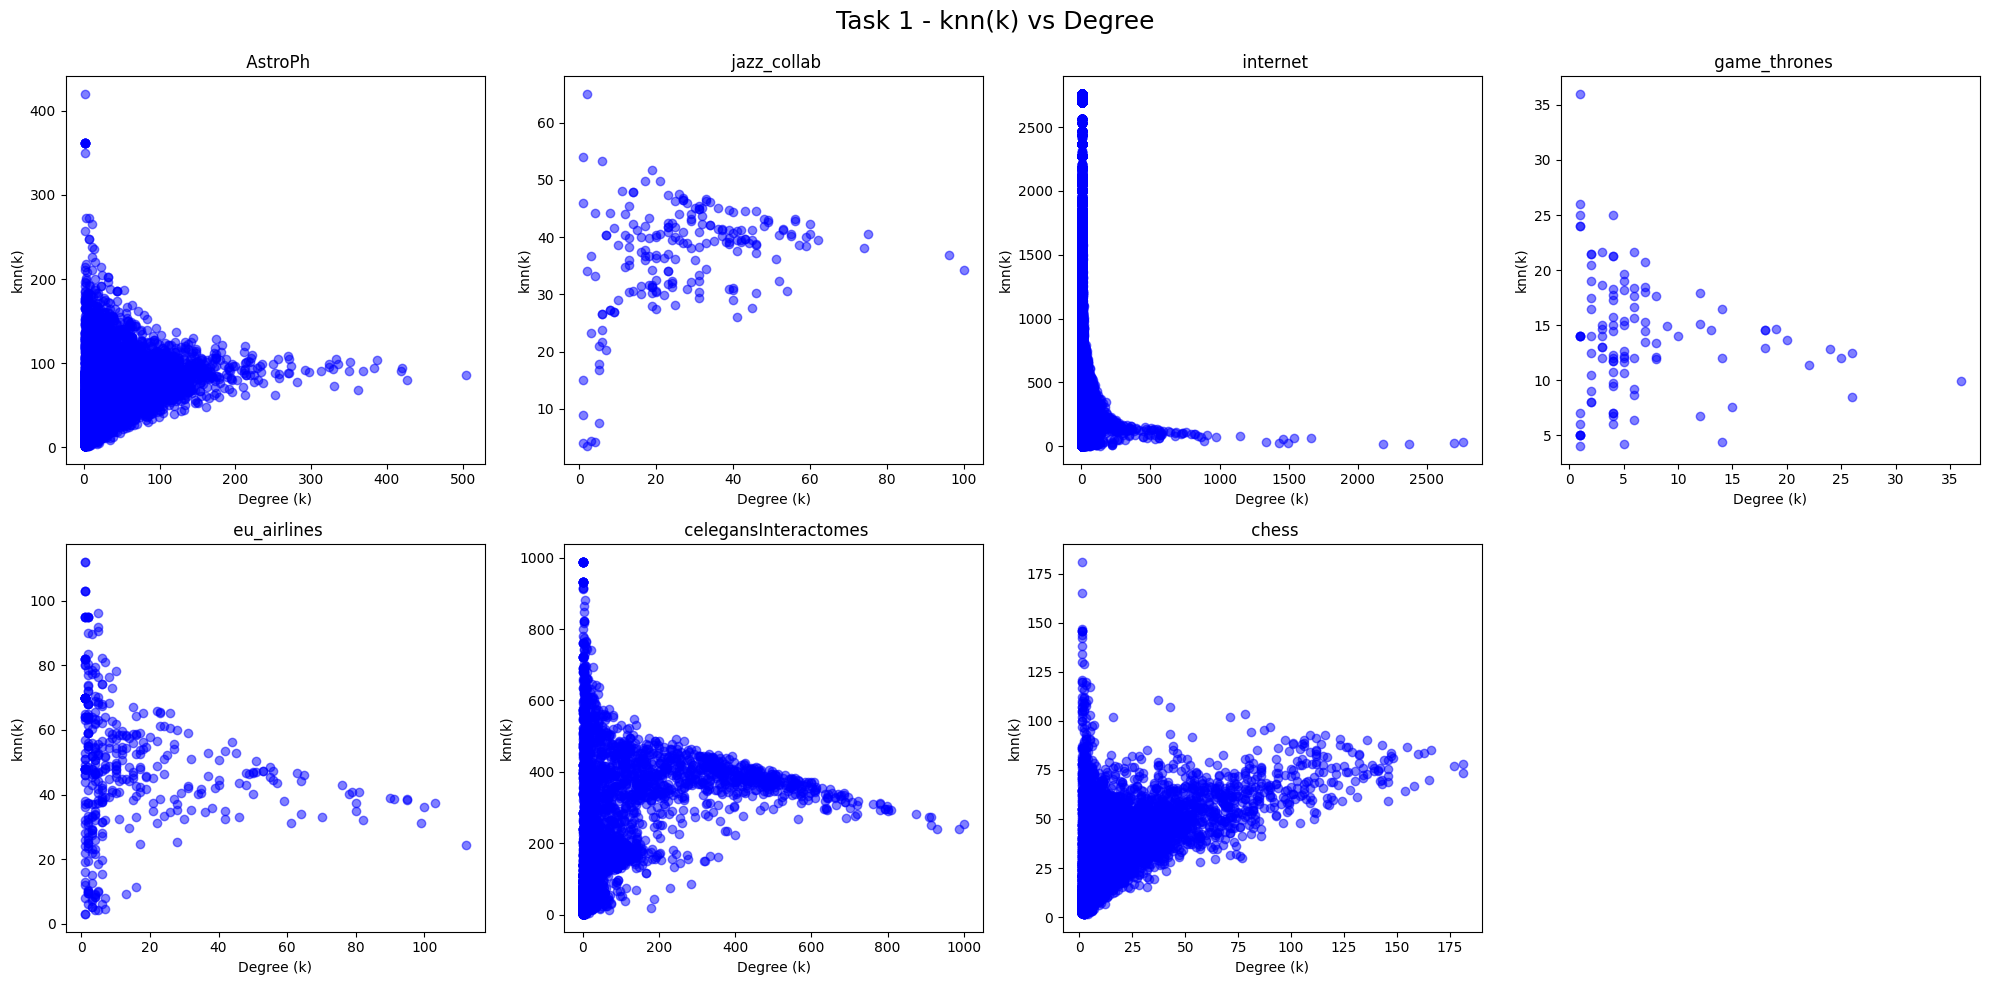

In [5]:
# plot the given network graphs
plot_ang_degree_of_graphs(data_lst)

## Task 2

In [6]:
#randomize the given network graphs
randomized_graphs = [nx.algorithms.smallworld.random_reference(g, connectivity = False) for g in data_lst]

# by definition, this does NOT change the degree of a node, hence in the new plots we can expect the distribution over the x-axis to remain the same compared to the ones for the original graph

In [7]:
def plot_original_and_randomized(og, rg, ax, title):
    
    # Get degree and knn for original graph
    knn_values_original, degrees_original = average_neighbor_degree(og)
    add_to_scatter(ax, degrees_original, knn_values_original, label="Original")
    
    # Get degree and knn for randomized graph
    knn_values_randomized, degrees_randomized = average_neighbor_degree(rg)
    add_to_scatter(ax, degrees_randomized, knn_values_randomized, col='r', label="Randomized")
    
    # Set axis labels and title for each subplot
    set_ax_labels(ax, "Degree (k)", "knn(k)", title=title)
    
    # Add a legend to differentiate between the two
    ax.legend()


In [18]:
def plot_ang_degree_comp(og, rg, title):

    fig, axes = initialize_figure(4, 2)

    for i, g in enumerate(og):
        plot_original_and_randomized(g, rg[i], axes[i], data_names[i])

    clean_figure(fig, axes, len(og), len(axes))
    
    fig.suptitle(title, fontsize=18)

    plt.tight_layout(rect=[0, 0, 1, 0.99])  # Leave space for the figure title

    return fig, axes

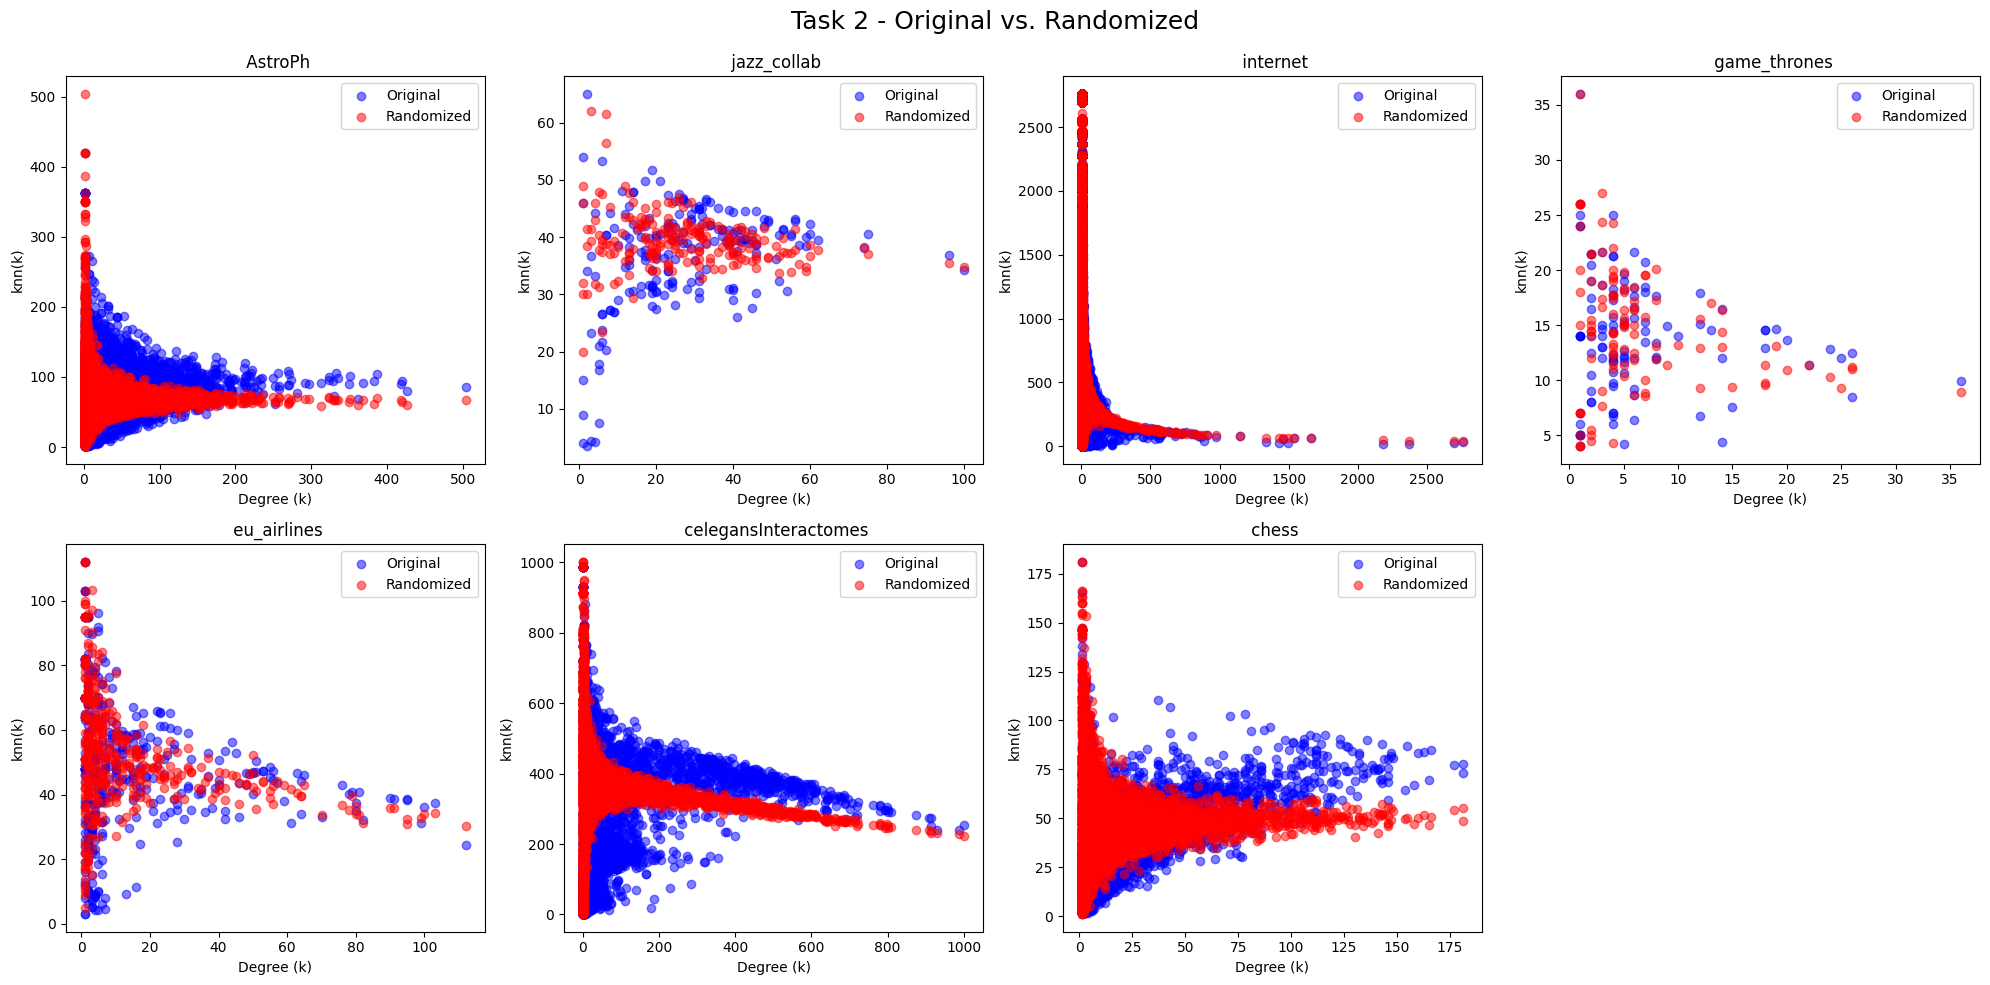

In [19]:
fig, axes = plot_ang_degree_comp(data_lst, randomized_graphs, "Task 2 - Original vs. Randomized")
plt.show()

## Task 3

In [20]:
#compute the assortativity coefficient of the network graphs
def assortativity(G):
    return nx.degree_assortativity_coefficient(G)

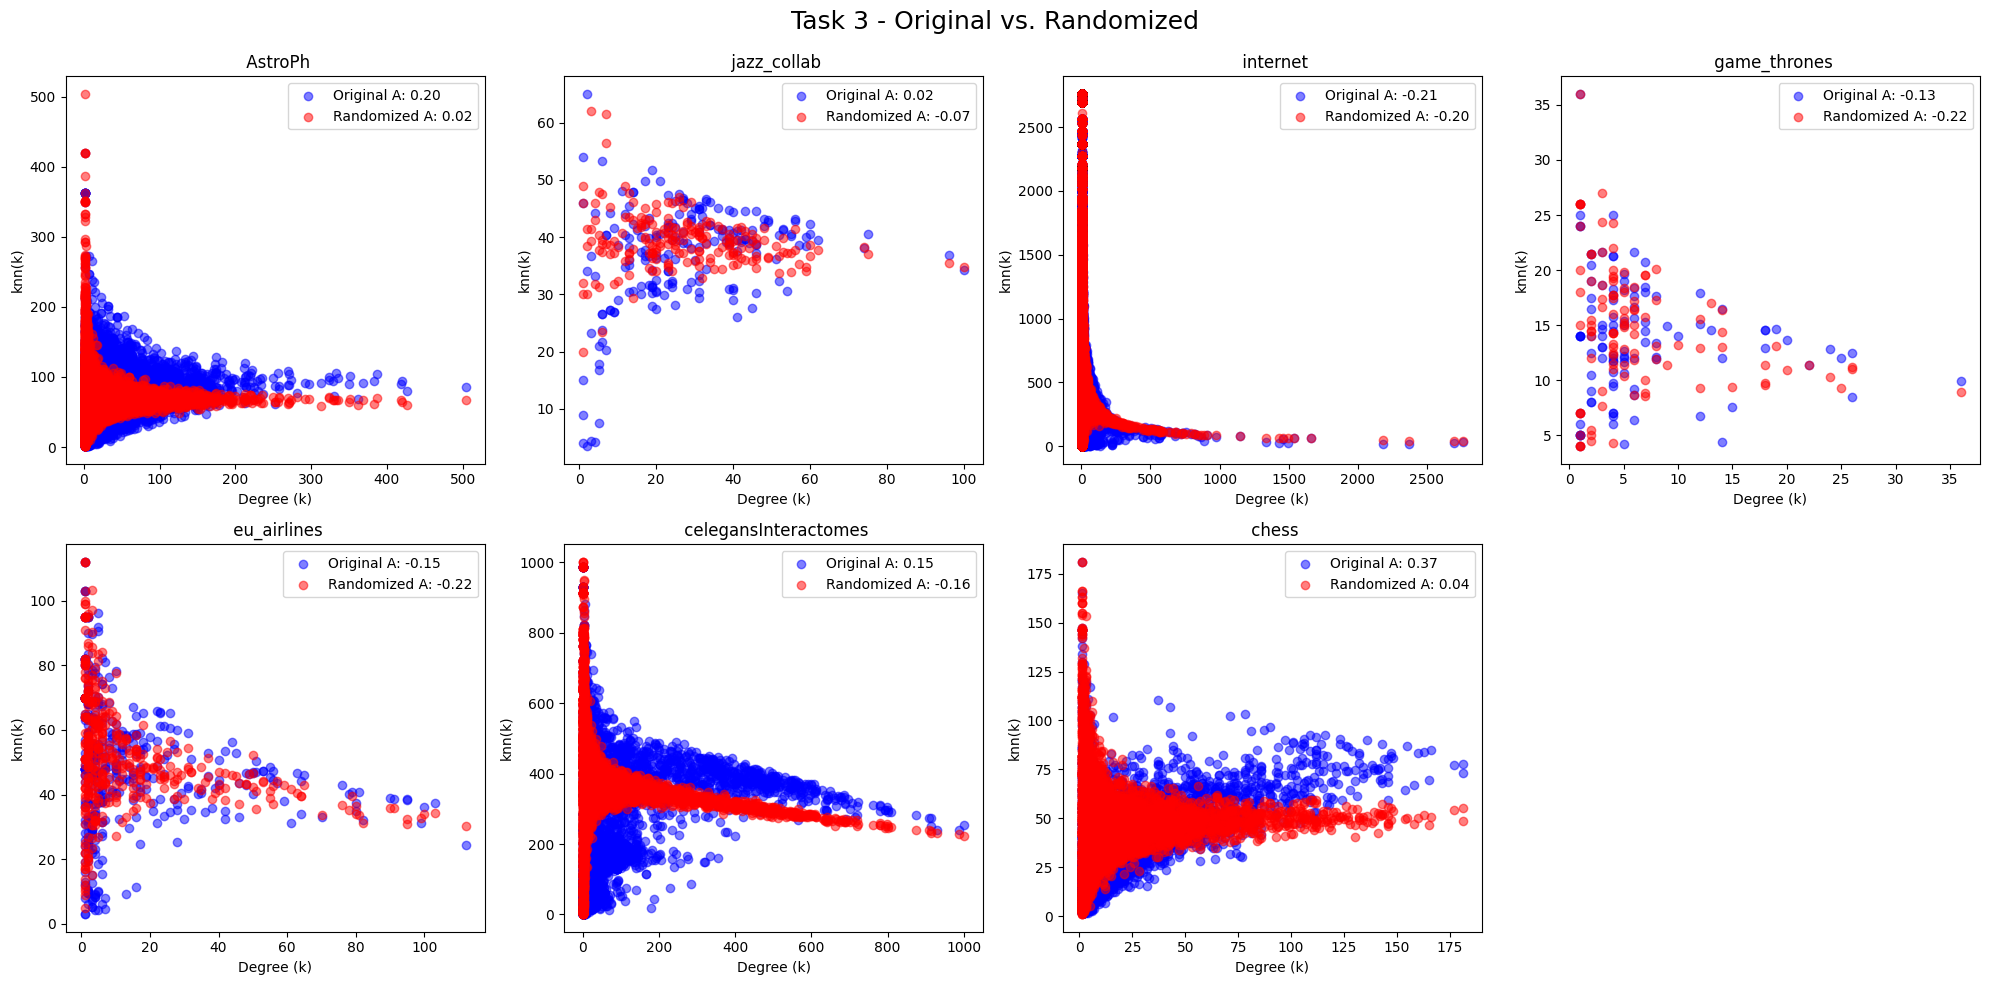

In [21]:
fig, axes = plot_ang_degree_comp(data_lst, randomized_graphs, "Task 3 - Original vs. Randomized")
for i,g in enumerate(data_lst):
    A_O = assortativity(g)
    A_R = assortativity(randomized_graphs[i])
    axes[i].legend([f"Original A: {A_O:.2f}", f"Randomized A: {A_R:.2f}"])
plt.show()

## Task 4

In [85]:
def degree_dist(g):
    degree = list(dict(g.degree()).values())
    return degree

In [92]:
def plot_degree_dist(g, ax, title=None):
    degrees_o = degree_dist(g)
    bins = np.logspace(np.log10(1), np.log10(max(degrees_o)), 20)

    ax.hist(degrees_o, bins=bins, density=True) 
    ax.set_xscale('log')
    ax.set_yscale('log')

    set_ax_labels(ax, "Degree (k)", "Density (p(k))", f"{title}")


def plot_degree_distributions(data_list):
    fig, axes = initialize_figure(4,2)

    for i, g in enumerate(data_list):
        plot_degree_dist(g, axes[i], title=data_names[i])
    
    clean_figure(fig, axes, len(data_lst), len(axes))
    
    fig.suptitle("Task 4 - Degree Distributions", fontsize=18)

    plt.tight_layout(rect=[0, 0, 1, 0.99]) 

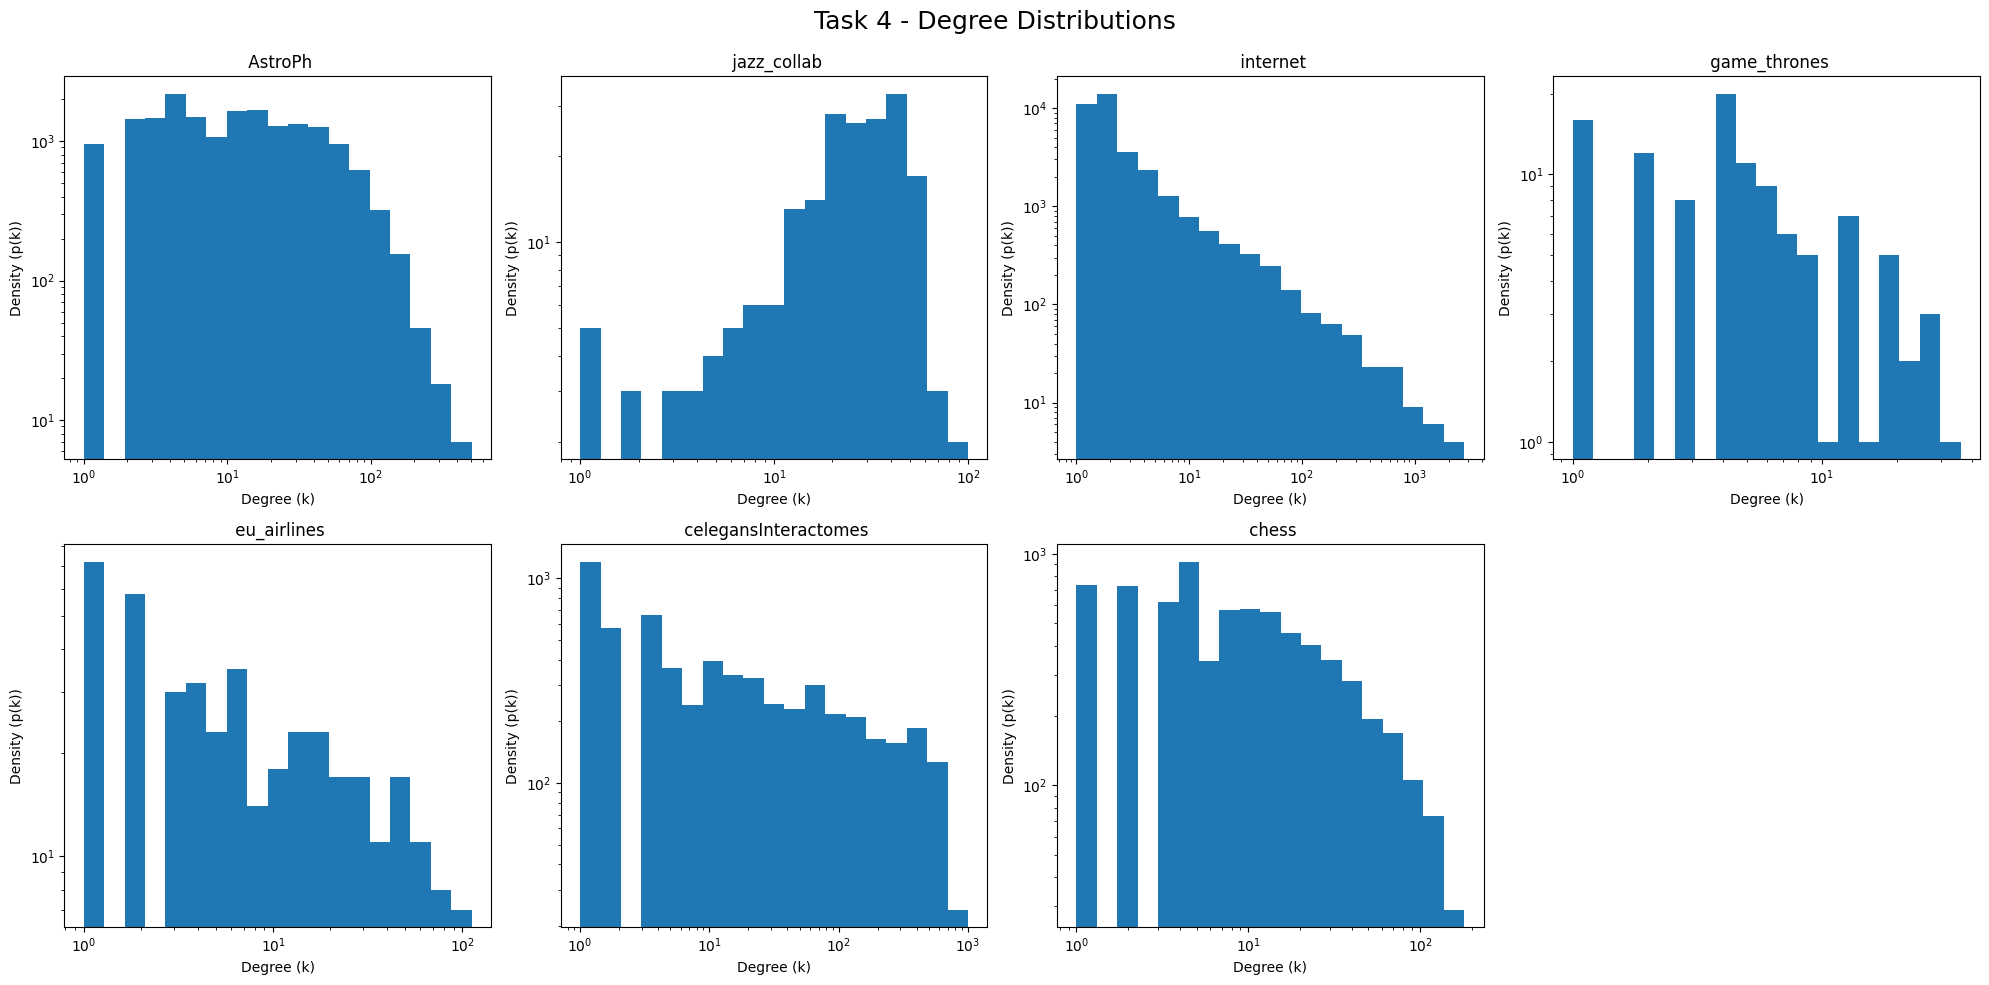

In [93]:
plot_degree_distributions(data_lst)